# TF — Segmentación no supervisada (PCA + KMeans + t-SNE)

**Proyecto**: Dinámica de precios residenciales en Dinamarca 1992–2024
**Curso**: Data Visualization — UPC 2026-01
**Equipo**: Vilchez · Ballón · Velásquez Borasino
**Entrega**: 6 (TF) — Técnica analítica requerida: reducción de dimensionalidad + clustering

**Fuente de verdad**: este notebook **reusa las funciones** de `scripts/run_segmentation.py`
(pipeline autoritativo y reproducible) y los parámetros de `configs/analysis.yaml -> segmentation`.
No duplica la lógica de features/PCA/KMeans/t-SNE — la importa. El notebook aporta la **narrativa
analítica** (por qué esta técnica, qué significa cada resultado, qué haría un inversor con esto)
que el script, por diseño, no incluye.

**Pregunta de investigación conectada**: ¿qué tipologías y regiones concentran el mayor riesgo
residencial y cómo influye el ciclo de tasas hipotecarias? Este notebook aborda la mitad
geográfica de esa pregunta con una técnica *data-driven*, sin imponer la región como input.


## 1. Contexto y pregunta analítica

Hasta TB4, la "segmentación" del proyecto era **por reglas**: flags definidos a mano
(`es_capital`, `es_summerhouse`, terciles de tamaño, período macro). Esas reglas son útiles como
filtros de dashboard, pero **imponen** la estructura en vez de descubrirla.

La Entrega 6 exige una técnica **no supervisada** de reducción de dimensionalidad + clustering
(PCA / t-SNE / KMeans) que deje que los datos hablen. La aplicamos sobre una pregunta concreta,
alineada con las hipótesis del proyecto:

> **¿Se agrupan los códigos postales daneses en perfiles de riesgo-retorno homogéneos, y esos
> grupos coinciden con la división Capital (København/Zealand) vs. Provincias (Jutland) que
> plantea H2? ¿Qué tipologías/zonas concentran más drawdown y volatilidad (H3)?**

Un punto metodológico importante desde el inicio: **la región NO se usa como input** del
clustering. Si el modelo reconstruye una división geográfica, es una señal *emergente*, no
circular — pero, como se discute en la sección 8, las features sí derivan de precios que están
correlacionados con la región, así que el resultado es *consistente con* H2, no una prueba
independiente de ella.

**Por qué le importa esto al cliente (inversor/decisor):** un mapa de zonas coloreado por
perfil de riesgo-retorno (no solo por precio absoluto) permite decidir *dónde concentrar o evitar
exposición* — el objetivo final es alimentar la vista de mapa del dashboard con esa capa.


In [1]:
import sys, warnings
from pathlib import Path

import numpy as np
import pandas as pd
import yaml

warnings.filterwarnings("ignore")
pd.set_option("display.max_columns", 30)
pd.set_option("display.width", 160)

# Localizar la raíz del proyecto (donde vive configs/analysis.yaml) para poder
# importar scripts/run_segmentation.py como módulo, en vez de reimplementar su lógica.
ROOT = Path.cwd()
while ROOT != ROOT.parent and not (ROOT / "configs" / "analysis.yaml").exists():
    ROOT = ROOT.parent

sys.path.insert(0, str(ROOT / "scripts"))
sys.path.insert(0, str(ROOT))

import run_segmentation as seg  # noqa: E402  (fuente autoritativa de la lógica)

print("ROOT:", ROOT)
print("Funciones reusadas de run_segmentation.py:",
      [f for f in ["build_features", "choose_k", "label_clusters", "run", "_plot"] if hasattr(seg, f)])


ROOT: /home/chris/Documentos/u/dataviz/danish-housing-analysis
Funciones reusadas de run_segmentation.py: ['build_features', 'choose_k', 'label_clusters', 'run', '_plot']


In [2]:
CONFIG_PATH = ROOT / "configs" / "analysis.yaml"
cfg_all = yaml.safe_load(CONFIG_PATH.read_text(encoding="utf-8"))
scfg = cfg_all["segmentation"]

print("Parametros de configs/analysis.yaml -> segmentation:")
for k, v in scfg.items():
    print(f"  {k}: {v}")


Parametros de configs/analysis.yaml -> segmentation:
  input_mart: mart_transactions_map
  min_years_coverage: 10
  min_avg_transactions: 15
  winsorize_pct: 0.01
  smoothing_years: 2
  recent_years: 5
  random_state: 42
  pca_components: 2
  kmeans_k_range: [2, 3, 4, 5, 6, 7, 8]
  kmeans_k_override: None
  tsne_perplexity: 30
  features: ['price_level', 'cagr_real', 'volatility', 'max_drawdown', 'liquidity_log', 'growth_recent']


## 2. Construcción de features por `zip_code`

Partimos del mart Gold real `mart_transactions_map.csv` (grano `year × zip_code`, 24 124 filas,
1992–2024) y colapsamos cada código postal a un vector de **6 features interpretables** de
perfil riesgo-retorno, usando `build_features()` de `scripts/run_segmentation.py`:

| Feature | Definición | Lectura de negocio |
|---|---|---|
| `price_level` | mediana de `avg_sqm_price_real` en los últimos `recent_years` años | nivel de precio real/m² — ticket de entrada |
| `cagr_real` | crecimiento anual compuesto del precio real (extremos suavizados) | retorno histórico anualizado |
| `volatility` | desvío estándar del cambio interanual del precio | riesgo de fluctuación año a año |
| `max_drawdown` | peor caída pico-valle (%) de la serie anual | riesgo de cola / pérdida máxima posible |
| `liquidity_log` | `log(1 + volumen medio de transacciones/año)` | qué tan fácil es entrar/salir de esa zona |
| `growth_recent` | crecimiento del precio en la ventana reciente | momentum actual (¿sigue subiendo o se enfrió?) |

Estas 6 variables son la entrada de PCA / KMeans / t-SNE — ninguna otra columna se usa para
clustering (la región y la ciudad se conservan solo como metadato para leer los resultados
después, no entran al modelo).


In [3]:
df_map = pd.read_csv(ROOT / "data" / "marts" / f"{scfg['input_mart']}.csv", dtype={"zip_code": str})
print(f"{scfg['input_mart']}.csv: {len(df_map):,} filas, {df_map['zip_code'].nunique()} zips unicos")
df_map.head()


mart_transactions_map.csv: 24,124 filas, 932 zips unicos


,year,zip_code,city,region,avg_sqm_price_real,n_transactions
0,1992,1051,København K,Zealand,9936.1,1
1,1992,1052,København K,Zealand,45949.5,12
2,1992,1112,København K,Zealand,17933.4,1
3,1992,1127,København K,Zealand,24186.5,1
4,1992,1201,København K,Zealand,13129.8,1


In [4]:
feats = seg.build_features(df_map, scfg)
n_total_zips = df_map["zip_code"].nunique()
n_ok = len(feats)
n_excluidos = n_total_zips - n_ok
print(f"Zips totales en el mart: {n_total_zips}")
print(f"Zips que superan los filtros de calidad: {n_ok}")
print(f"Zips excluidos: {n_excluidos}")
feats.head()


12:19:32 [INFO] Features construidas: 483 zips (de 932) sobrevivieron los filtros de cobertura


Zips totales en el mart: 932
Zips que superan los filtros de calidad: 483
Zips excluidos: 449


,zip_code,city,region,n_years,price_level,cagr_real,volatility,max_drawdown,liquidity_log,growth_recent
0,1799,København V,Zealand,13,63940.2,0.039619,1.116190,-21.440629,4.623463,-0.017010
1,2000,Frederiksberg,Zealand,33,53766.0,0.032521,0.215814,-38.584510,5.485174,0.030990
2,2100,København A,Zealand,33,54205.7,0.012267,2.844999,-94.285469,5.389072,7.735354
3,2150,Nordhavn,Zealand,12,65984.5,0.033713,0.074234,-7.340812,4.263853,-0.018012
4,2200,København N,Zealand,33,54698.3,0.000794,0.267778,-61.258841,4.983399,0.057005


## 3. Filtros de calidad y winsorización — el sesgo de selección

Los filtros de `configs/analysis.yaml -> segmentation` son:

- `min_years_coverage = 10` años de historia mínima por zip (evita series cortas y ruidosas).
- `min_avg_transactions = 15` transacciones/año promedio mínimas (evita mercados erráticos de
  muy baja liquidez, donde un puñado de ventas puede mover el precio medio artificialmente).

**Hay que declararlo honestamente**: estos filtros excluyen sistemáticamente los códigos postales
más pequeños y rurales — no es una muestra aleatoria. El análisis que sigue describe **solo los
mercados líquidos** (~la mitad de los zips daneses). Las conclusiones sobre riesgo-retorno no se
extrapolan automáticamente a los ~449 zips rurales excluidos, que probablemente son *aún más*
volátiles por su bajo volumen, pero no hay suficiente historia/liquidez para medirlo con
confianza estadística.

Adicionalmente, cada feature se recorta a `[p1, p99]` (`winsorize_pct = 0.01`) antes de
estandarizar, para que un zip atípico (p.ej. un mercado de nicho con un salto de precio puntual)
no capture un cluster de tamaño 1 por sí solo.


In [5]:
feature_cols = scfg["features"]
wp = scfg.get("winsorize_pct", 0.0)

Xraw = feats[feature_cols].copy()
print("Antes de winsorizar:")
display(Xraw.describe().T[["min", "mean", "max"]])

if wp and wp > 0:
    lo = Xraw.quantile(wp)
    hi = Xraw.quantile(1 - wp)
    Xraw_w = Xraw.clip(lower=lo, upper=hi, axis=1)
else:
    Xraw_w = Xraw

print(f"\nDespues de winsorizar a [p{wp*100:.0f}, p{(1-wp)*100:.0f}]:")
display(Xraw_w.describe().T[["min", "mean", "max"]])


Antes de winsorizar:


,min,mean,max
price_level,5057.600000,18606.272050,65984.500000
cagr_real,-0.023225,0.017953,0.054482
volatility,0.074234,0.311549,5.675043
max_drawdown,-96.813793,-52.473265,-7.340812
liquidity_log,2.774481,4.051172,6.288196
growth_recent,-0.572237,0.001237,7.735354



Despues de winsorizar a [p1, p99]:


,min,mean,max
price_level,6824.578000,18558.338820,54248.972000
cagr_real,-0.013694,0.017980,0.042142
volatility,0.090145,0.294640,1.237450
max_drawdown,-90.137032,-52.487586,-23.292337
liquidity_log,2.792874,4.050053,6.038377
growth_recent,-0.481993,-0.015003,0.561306


## 4. Estandarización y PCA

Las 6 features tienen escalas muy distintas (`price_level` en decenas de miles de DKK vs.
`volatility` en `[0, 1]`). Sin estandarizar, `price_level` dominaría por completo la distancia
euclídea que usan PCA y KMeans. Aplicamos `StandardScaler` (media 0, desvío 1) y luego PCA sobre
la matriz estandarizada.


In [6]:
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

rs = scfg["random_state"]

scaler = StandardScaler()
X = scaler.fit_transform(Xraw_w.to_numpy())

pca = PCA(n_components=scfg["pca_components"], random_state=rs)
pcs = pca.fit_transform(X)
var = pca.explained_variance_ratio_

print(f"PCA: {len(var)} componentes explican {var.sum()*100:.1f}% de la varianza total")
for i, v in enumerate(var, start=1):
    print(f"  PC{i}: {v*100:.1f}%")


PCA: 2 componentes explican 63.6% de la varianza total
  PC1: 43.4%
  PC2: 20.2%


,PC1,PC2
price_level,0.449,0.078
cagr_real,0.441,0.444
volatility,-0.453,0.271
max_drawdown,0.530,-0.185
liquidity_log,0.287,-0.474
growth_recent,0.185,0.681


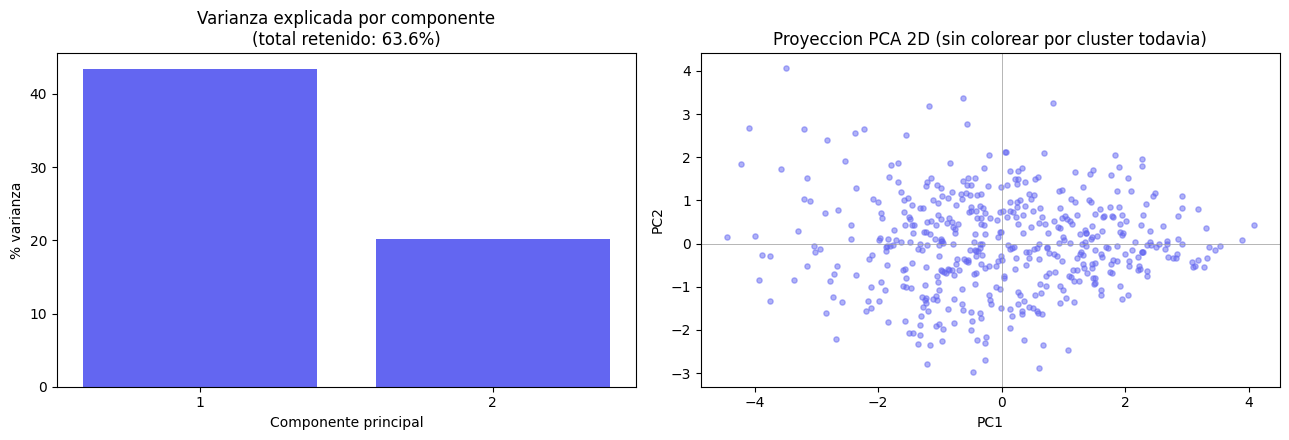

In [7]:
import matplotlib.pyplot as plt

loadings = pd.DataFrame(pca.components_.T, index=feature_cols, columns=[f"PC{i+1}" for i in range(len(var))])
display(loadings.round(3))

fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))

axes[0].bar(range(1, len(var) + 1), var * 100, color="#6366f1")
axes[0].set_title(f"Varianza explicada por componente\n(total retenido: {var.sum()*100:.1f}%)")
axes[0].set_xlabel("Componente principal")
axes[0].set_ylabel("% varianza")
axes[0].set_xticks(range(1, len(var) + 1))

axes[1].scatter(pcs[:, 0], pcs[:, 1], s=14, alpha=0.5, color="#6366f1")
axes[1].axhline(0, color="#999", lw=0.5)
axes[1].axvline(0, color="#999", lw=0.5)
axes[1].set_title("Proyeccion PCA 2D (sin colorear por cluster todavia)")
axes[1].set_xlabel("PC1")
axes[1].set_ylabel("PC2")

fig.tight_layout()
plt.show()


**Lectura de PC1** (mirando la tabla de *loadings*): PC1 es el eje dominante de **riesgo-retorno** —
zips con `price_level` alto y `cagr_real` alto cargan positivo, junto con `volatility` y
`max_drawdown` cargando negativo (menos riesgo). En el extremo opuesto quedan zips de precio bajo,
crecimiento plano, alta volatilidad y drawdowns profundos. PC2 aporta un matiz secundario, en
general ligado a liquidez/crecimiento reciente.

Que **2 componentes solo alcancen ~64%** de la varianza (y que ningún componente domine con >50%)
ya es un diagnóstico en sí mismo: el mercado no es perfectamente unidimensional, hay algo de
estructura adicional más allá del eje riesgo-retorno principal — lo cual anticipa por qué la
silueta del clustering (sección 5) va a ser moderada y no muy alta.


## 5. Selección de `k` por coeficiente de silueta

El número de clusters se elige **por datos**, no a criterio: se corre KMeans para
`k ∈ {2, ..., 8}` (rango de `configs/analysis.yaml`) sobre las 6 features estandarizadas
(no sobre los 2 PCs, para no descartar el ~36% de varianza residual) y se mide la silueta de
cada solución con `choose_k()` de `run_segmentation.py`.


12:19:33 [INFO]   k=2 -> silueta=0.2654


12:19:33 [INFO]   k=3 -> silueta=0.2307


12:19:34 [INFO]   k=4 -> silueta=0.2335


12:19:34 [INFO]   k=5 -> silueta=0.2174


12:19:34 [INFO]   k=6 -> silueta=0.2078


12:19:34 [INFO]   k=7 -> silueta=0.2062


12:19:34 [INFO]   k=8 -> silueta=0.1994


12:19:34 [INFO] k elegido por silueta = 2 (silueta=0.2654)


,k,silueta
0,2,0.265442
1,3,0.230736
2,4,0.233544
3,5,0.217450
4,6,0.207838
5,7,0.206241
6,8,0.199432


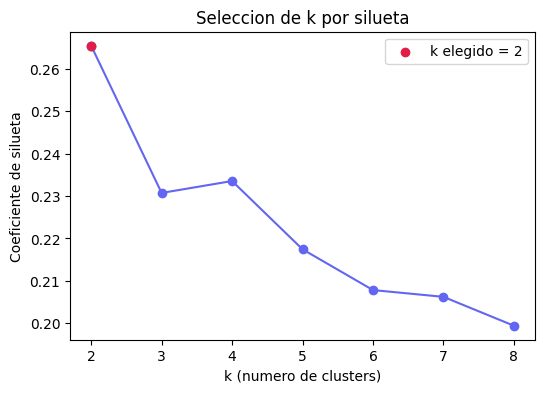


k elegido = 2 (silueta = 0.265)


In [8]:
k, sil_scores = seg.choose_k(X, scfg["kmeans_k_range"], scfg["kmeans_k_override"], rs)

sil_df = pd.DataFrame({"k": list(sil_scores.keys()), "silueta": list(sil_scores.values())})
display(sil_df)

fig, ax = plt.subplots(figsize=(6, 4))
ax.plot(sil_df["k"], sil_df["silueta"], marker="o", color="#6366f1")
ax.scatter([k], [sil_scores[k]], color="#e11d48", zorder=5, label=f"k elegido = {k}")
ax.set_xlabel("k (numero de clusters)")
ax.set_ylabel("Coeficiente de silueta")
ax.set_title("Seleccion de k por silueta")
ax.legend()
plt.show()

print(f"\nk elegido = {k} (silueta = {sil_scores[k]:.3f})")


**Hay que ser honesto sobre lo que dice esta cifra.** La silueta máxima es ~0.27 en `k=2` —
un valor que indica **estructura moderada**, no clusters netamente disjuntos. Valores de silueta
por debajo de ~0.5 sugieren superposición sustancial entre grupos. La lectura correcta no es
"hay dos poblaciones separadas de zips", sino: **el mercado danés de vivienda es un continuo
riesgo-retorno con dos modos** (una moda cara/estable, una moda barata/volátil), y `k=2` es la
partición más nítida disponible de ese continuo — no una frontera dura entre categorías
naturales.


## 6. KMeans y perfiles de cluster

Con `k` fijado, corremos KMeans sobre las 6 features estandarizadas y construimos el perfil
(centroide) de cada cluster con `label_clusters()` de `run_segmentation.py` — la etiqueta se
deriva de terciles relativos de precio, crecimiento y volatilidad, no es texto libre arbitrario.


In [9]:
from sklearn.cluster import KMeans

km = KMeans(n_clusters=k, random_state=rs, n_init=10)
feats["cluster"] = km.fit_predict(X)
feats["pca1"], feats["pca2"] = pcs[:, 0], pcs[:, 1]

profiles = (
    feats.groupby("cluster")
    .agg(n_zips=("zip_code", "count"), **{c: (c, "mean") for c in feature_cols})
    .reset_index()
)
labels = seg.label_clusters(profiles)
profiles["cluster_label"] = profiles["cluster"].map(labels)
feats["cluster_label"] = feats["cluster"].map(labels)

reg_dom = feats.groupby("cluster")["region"].agg(lambda s: s.value_counts().idxmax())
reg_share = feats.groupby("cluster")["region"].value_counts(normalize=True)
profiles["region_dominante"] = profiles["cluster"].map(reg_dom)

with pd.option_context("display.width", 160, "display.max_columns", 20):
    display(profiles[["cluster", "cluster_label", "n_zips", "region_dominante",
                       "price_level", "cagr_real", "volatility", "max_drawdown",
                       "liquidity_log", "growth_recent"]].round(3))


,cluster,cluster_label,n_zips,region_dominante,price_level,cagr_real,volatility,max_drawdown,liquidity_log,growth_recent
0,0,Precio alto / dinamico / estable,229,Zealand,24847.782,0.025,0.188,-41.911,4.390,0.050
1,1,Precio bajo / plano / volatil,254,Jutland,12979.084,0.011,0.423,-61.996,3.746,-0.043


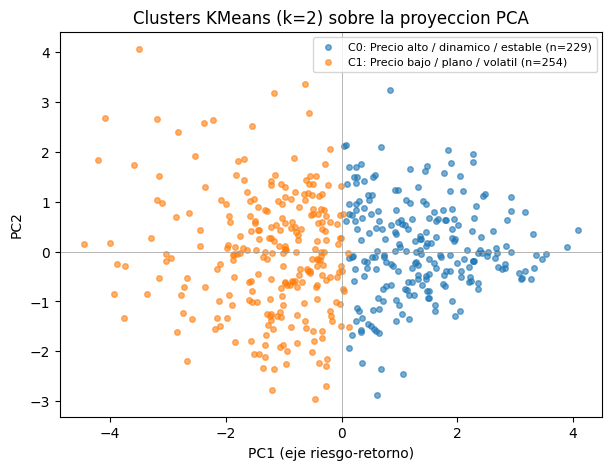

In [10]:
fig, ax = plt.subplots(figsize=(7, 5))
cmap = plt.get_cmap("tab10")
for c in sorted(feats["cluster"].unique()):
    sub = feats[feats["cluster"] == c]
    lbl = labels[c]
    ax.scatter(sub["pca1"], sub["pca2"], s=16, alpha=0.6, color=cmap(c), label=f"C{c}: {lbl} (n={len(sub)})")
ax.axhline(0, color="#999", lw=0.5)
ax.axvline(0, color="#999", lw=0.5)
ax.set_xlabel("PC1 (eje riesgo-retorno)")
ax.set_ylabel("PC2")
ax.set_title(f"Clusters KMeans (k={k}) sobre la proyeccion PCA")
ax.legend(fontsize=8, loc="best")
plt.show()


**Lectura de negocio de los centroides**: el cluster de **precio alto / dinámico / estable**
combina el ticket de entrada más alto con el mayor CAGR *y* el menor drawdown/volatilidad — el
perfil más defensivo y a la vez más rentable en términos de retorno histórico. El cluster de
**precio bajo / plano / volátil** es el peor binomio riesgo-retorno: crecimiento más lento *y*
caídas más profundas. No hay un cluster "barato pero estable" ni "caro pero volátil" — precio,
retorno y riesgo se mueven juntos, lo cual es coherente con PC1 explicando la mayor parte de la
varianza retenida.

Para un inversor, esto es la señal más accionable de todo el análisis: **el mercado no ofrece un
trade-off clásico "más riesgo, más retorno"** en esta muestra de zips líquidos — los zips caros
son simultáneamente los de mejor retorno *y* menor riesgo. Los zips de menor ticket de entrada,
lejos de compensar con mayor crecimiento, muestran peor retorno y peor riesgo.


In [11]:
# Zips mas representativos de cada extremo (mayor |pca1|) — utiles para nombrar el cluster
top_n = 6
for c in sorted(feats["cluster"].unique()):
    sub = feats[feats["cluster"] == c].copy()
    sub["dist_centro"] = (sub["pca1"] - sub["pca1"].mean()).abs()
    ejemplo = sub.sort_values("price_level", ascending=False).head(top_n)
    print(f"\nCluster {c} ({labels[c]}) — zips de mayor precio real/m2:")
    display(ejemplo[["zip_code", "city", "region", "price_level", "cagr_real", "volatility", "max_drawdown"]])



Cluster 0 (Precio alto / dinamico / estable) — zips de mayor precio real/m2:


,zip_code,city,region,price_level,cagr_real,volatility,max_drawdown
3,2150,Nordhavn,Zealand,65984.5,0.033713,0.074234,-7.340812
0,1799,København V,Zealand,63940.2,0.039619,1.116190,-21.440629
42,2930,Klampenborg,Zealand,59200.1,0.025579,0.203173,-44.630121
4,2200,København N,Zealand,54698.3,0.000794,0.267778,-61.258841
40,2900,Hellerup,Zealand,54446.1,0.043846,0.156321,-29.406451
1,2000,Frederiksberg,Zealand,53766.0,0.032521,0.215814,-38.584510



Cluster 1 (Precio bajo / plano / volatil) — zips de mayor precio real/m2:


,zip_code,city,region,price_level,cagr_real,volatility,max_drawdown
2,2100,København A,Zealand,54205.7,0.012267,2.844999,-94.285469
350,8230,Ã byhøj,Jutland,35739.5,0.033115,5.675043,-96.813793
349,8220,Brabrand,Jutland,28403.5,-0.004922,0.603702,-80.098824
55,3140,Ã lsgårde,Zealand,27938.8,0.031292,1.083781,-87.537775
412,8900,Randers C,Jutland,24049.5,-0.021214,0.508774,-70.697709
142,4622,Havdrup,Zealand,23495.0,0.029597,0.507797,-66.823766


## 7. t-SNE — exploración visual complementaria

Calculamos un embedding **t-SNE** 2D (`perplexity=30`, `init="pca"`, `random_state=42`) como
**exploración visual complementaria**, no como validación. t-SNE no preserva distancias globales
y puede **exagerar o inventar separaciones** que no reflejan la geometría real del espacio de
features — verlo separado en t-SNE no "confirma" que los clusters de KMeans sean correctos, ni
verlo mezclado los refutaría necesariamente. Se usa aquí únicamente para tener una segunda vista
no lineal de la misma estructura.


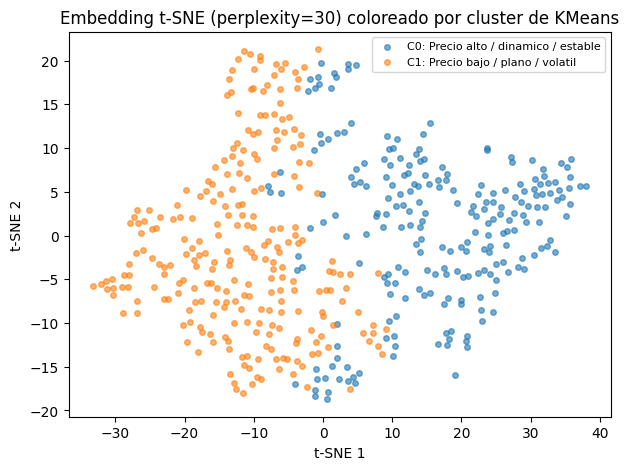

In [12]:
from sklearn.manifold import TSNE

perp = min(scfg["tsne_perplexity"], (len(feats) - 1) // 3)
tsne = TSNE(n_components=2, perplexity=perp, random_state=rs, init="pca")
emb = tsne.fit_transform(X)
feats["tsne1"], feats["tsne2"] = emb[:, 0], emb[:, 1]

fig, ax = plt.subplots(figsize=(7, 5))
for c in sorted(feats["cluster"].unique()):
    sub = feats[feats["cluster"] == c]
    ax.scatter(sub["tsne1"], sub["tsne2"], s=16, alpha=0.6, color=cmap(c), label=f"C{c}: {labels[c]}")
ax.set_xlabel("t-SNE 1")
ax.set_ylabel("t-SNE 2")
ax.set_title(f"Embedding t-SNE (perplexity={perp}) coloreado por cluster de KMeans")
ax.legend(fontsize=8)
plt.show()


El embedding t-SNE es **coherente con la estructura encontrada** por KMeans/PCA: los dos
grupos ocupan regiones mayormente separadas del plano. Esto es tranquilizador pero no concluyente
— dado que t-SNE se inicializó con PCA y los inputs son los mismos, cierto grado de coherencia es
esperable casi por construcción. No se reporta esta figura como prueba independiente de que los
clusters "existen" en la realidad, sino como una vista adicional consistente con el resto del
análisis.


## 8. Integración: qué hace el cliente con esto

**Uso directo en el dashboard**: el mart `mart_zip_segments.csv` añade la columna `cluster_label`
a nivel de código postal. Esto permite colorear el **mapa coroplético** (vista de Geografía) por
perfil de riesgo-retorno en vez de por precio absoluto — un decisor puede filtrar visualmente
"muéstrame solo las zonas de perfil defensivo" o "dónde está concentrado el riesgo de cola", sin
tener que leer una tabla de drawdowns por región.

**Sobre H2 — matiz importante**: los resultados son ***consistentes con*** H2 (la división
Capital/Zealand vs. Provincias/Jutland en resiliencia de precios), no una **confirmación
independiente** de ella. La razón: las 6 features de entrada (precio, CAGR, volatilidad,
drawdown) están construidas a partir de la misma serie de precios reales que ya sabíamos
correlacionada con la región — el clustering no aporta una fuente de evidencia distinta a la
de las Vistas 1/2 del dashboard, aporta una **agregación distinta** (a nivel zip, no a nivel
región/trimestre) de la misma señal subyacente. Que la región dominante de cada cluster difiera
(ver `region_dominante` en la tabla de perfiles) es un dato interesante y útil operativamente,
pero metodológicamente circular llamarlo "confirmación" cuando price/cagr/drawdown ya eran, por
diseño, las variables donde H2 se manifiesta.

**Sobre H3**: el hallazgo más nuevo de esta técnica es que el riesgo no se reparte solo por
tipología de vivienda (que ya se cuantifica en `mart_volatility.csv` y `mart_drawdowns.csv`) sino
también **geográficamente a nivel de zip** — dentro de una misma tipología, un inversor puede
todavía elegir entre zips de perfil defensivo u ofensivo según en qué cluster caigan.


In [13]:
# Exportar los mismos artefactos que scripts/run_segmentation.py, para dejar el notebook
# reproducible end-to-end sin depender de un run previo del script.
OUT_DIR = ROOT / "data" / "marts"
cols_seg = ["zip_code", "city", "region", "n_years", *feature_cols,
            "pca1", "pca2", "tsne1", "tsne2", "cluster", "cluster_label"]

print("Comparacion rapida con los marts ya trackeados (si existen):")
existing = OUT_DIR / "mart_zip_segments.csv"
if existing.exists():
    prev = pd.read_csv(existing, dtype={"zip_code": str})
    print(f"  mart_zip_segments.csv existente: {len(prev)} filas")
print(f"  Este notebook (recalculado): {len(feats)} filas, k={k}")

feats[cols_seg].round(4).to_csv(OUT_DIR / "mart_zip_segments_notebook_check.csv", index=False)
profiles.round(4).to_csv(OUT_DIR / "mart_segment_profiles_notebook_check.csv", index=False)
print("\nExportados *_notebook_check.csv en data/marts/ como verificacion cruzada")
print("(no reemplazan a los mart_zip_segments.csv / mart_segment_profiles.csv oficiales,")
print(" que se generan y versionan via scripts/run_segmentation.py)")


Comparacion rapida con los marts ya trackeados (si existen):
  mart_zip_segments.csv existente: 483 filas
  Este notebook (recalculado): 483 filas, k=2

Exportados *_notebook_check.csv en data/marts/ como verificacion cruzada
(no reemplazan a los mart_zip_segments.csv / mart_segment_profiles.csv oficiales,
 que se generan y versionan via scripts/run_segmentation.py)


## 9. Reproducibilidad y limitaciones

**Reproducir end-to-end** (fuera de este notebook, pipeline autoritativo):

```bash
uv run python scripts/run_segmentation.py --config configs/analysis.yaml
```

- Determinista: `random_state=42` fijado en `configs/analysis.yaml -> segmentation` y usado en
  PCA, KMeans y t-SNE.
- Todos los parámetros (filtros de cobertura, winsorización, columnas de features, rango de `k`,
  perplejidad de t-SNE) viven en el YAML — no hay números mágicos hardcodeados en este notebook
  ni en el script.
- Salidas oficiales: `data/marts/mart_zip_segments.csv`, `data/marts/mart_segment_profiles.csv`,
  `docs/refs/segmentation_pca_tsne.png` (generadas por el script, no por este notebook).

**Limitaciones**, para dejarlas explícitas y no maquilladas:

1. **Sesgo de selección**: los filtros de cobertura/liquidez excluyen ~449 de 932 zips (los más
   rurales y de menor volumen). El análisis describe el mercado líquido, no la totalidad del
   territorio.
2. **Estructura moderada, no clusters disjuntos**: silueta máxima ≈0.27 en k=2. El mercado es un
   continuo riesgo-retorno con dos modos, no dos poblaciones netamente separables.
3. **t-SNE es exploratorio, no confirmatorio**: puede exagerar separaciones; se usa como vista
   complementaria, nunca como evidencia independiente de que los clusters "son reales".
4. **La segmentación es descriptiva, no predictiva**: agrupa zonas por comportamiento histórico
   (1992–2024); no proyecta su evolución futura ni implica causalidad entre región y riesgo.
5. **H2 se relaciona, no se confirma de forma independiente**: las features de entrada ya
   incorporan la señal de precio/región que H2 describe; ver matiz completo en la sección 8.
